# Deutschlandkurier
Load Deutschlandkurier CSV files and create a DataFrame named `df`.


In [3]:
from pathlib import Path
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Deutschlandkurier"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()

print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")
df.head()


Loaded 1977 rows from 222 file(s) in /Users/MattisHaumann/Dev/Thesis/data/raw/Alternative Medien/Deutschlandkurier


,id,title,teaser,categories,lastModified,created,publishedAt,authors,url,article_text,source,source_file
0,92655,Autokrise: Auch BMW-Gewinne brechen massiv ein!,Die Horrormeldungen aus der Automobilbranche r...,Wirtschaft,2025-07-31T08:50:16+00:00,2025-07-31T08:50:16+00:00,2025-07-31T08:50:16+00:00,NaN,https://deutschlandkurier.de/2025/07/autokrise...,Die Horrormeldungen aus der Automobilbranche r...,Deutschlandkurier,deutschlandkurier_articles_2025-07-31.csv
1,92658,Verfassungsrichter: Top-Staatsrechtler Rupert ...,Vor dem Hintergrund des aktuellen Streits um d...,Politik,2025-07-31T11:59:26+00:00,2025-07-31T09:16:48+00:00,2025-07-31T09:16:48+00:00,NaN,https://deutschlandkurier.de/2025/07/verfassun...,Vor dem Hintergrund des aktuellen Streits um d...,Deutschlandkurier,deutschlandkurier_articles_2025-07-31.csv
2,92666,„Nazi-Codes!“ Woker Aufstand im Netz gegen Syd...,Die US-amerikanische Schauspielerin Sydney Swe...,Ausland,2025-07-31T11:09:19+00:00,2025-07-31T11:09:19+00:00,2025-07-31T11:09:19+00:00,NaN,https://deutschlandkurier.de/2025/07/nazi-code...,Die US-amerikanische Schauspielerin Sydney Swe...,Deutschlandkurier,deutschlandkurier_articles_2025-07-31.csv
3,92669,SPD löscht Wut-Attacke auf Union aus Online-Ka...,In einer Online-Kampagne hat die SPD ihren Koa...,Politik,2025-07-31T11:46:15+00:00,2025-07-31T11:46:15+00:00,2025-07-31T11:46:15+00:00,NaN,https://deutschlandkurier.de/2025/07/spd-loesc...,In einer Online-Kampagne hat die SPD ihren Koa...,Deutschlandkurier,deutschlandkurier_articles_2025-07-31.csv
4,92672,Bürgermeister von Hiddensee schreibt Alarm-Bri...,Der Bürgermeister der 1.000 Einwohner zählende...,Politik,2025-07-31T11:48:25+00:00,2025-07-31T11:48:25+00:00,2025-07-31T11:48:25+00:00,NaN,https://deutschlandkurier.de/2025/07/buergerme...,Der Bürgermeister der 1.000 Einwohner zählende...,Deutschlandkurier,deutschlandkurier_articles_2025-07-31.csv


In [4]:
# Short EDA prep: publishedAt -> Date and article_text -> Text
import pandas as pd

if "article_text" in df.columns and "Text" not in df.columns:
    df = df.rename(columns={"article_text": "Text"})
elif "article_text" in df.columns:
    df["Text"] = df["article_text"]

if "publishedAt" not in df.columns:
    raise KeyError("Spalte 'publishedAt' nicht gefunden.")

eda_df = df.copy()
eda_df["Date"] = pd.to_datetime(eda_df["publishedAt"], errors="coerce")
eda_df["Date"] = eda_df["Date"].dt.strftime("%Y.%m.%d")

eda_df["article_length_words"] = eda_df["Text"].astype("string").str.split().str.len()

eda_df[["Date", "article_length_words"]].head()


,Date,article_length_words
0,2025.07.31,104
1,2025.07.31,405
2,2025.07.31,188
3,2025.07.31,296
4,2025.07.31,417


In [10]:
# keep only articles with Date >= start_date (start_date already defined)
mask = pd.to_datetime(eda_df["Date"], format="%Y.%m.%d", errors="coerce") >= start_date

removed = (~mask).sum()
eda_df = eda_df.loc[mask].copy()
df = df.loc[mask].copy()  # keep df consistent with eda_df

# remove derived plot variables to avoid stale objects (they will be recomputed in later cells)
for _v in ("length_plot", "q99", "fig", "ax"):
    if _v in globals():
        del globals()[_v]

print(f"Removed {removed} articles. {len(eda_df)} articles remain (from {start_date.date()}).")

Removed 0 articles. 1968 articles remain (from 2025-08-01).


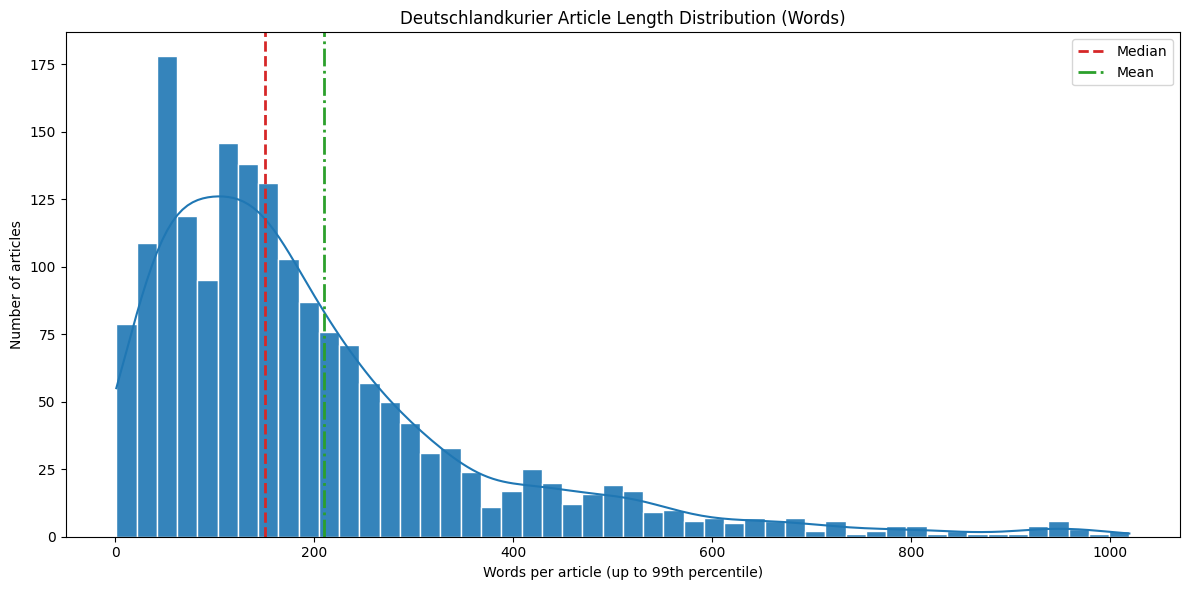

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

q99 = eda_df["article_length_words"].quantile(0.99)
length_plot = eda_df[eda_df["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(eda_df["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(eda_df["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("Deutschlandkurier Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()
